https://www.datacamp.com/tutorial/langgraph-tutorial

In [12]:
%%capture
!pip install langchain_community langgraph-checkpoint-sqlite tiktoken langchain-openai langchainhub chromadb langchain langgraph tavily-python

In [2]:
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from google.colab import userdata

llm = AzureChatOpenAI(
    model=userdata.get('AZURE_MODEL_NAME'),
    deployment_name=userdata.get('AZURE_MODEL_NAME'),
    temperature=0,
    # max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=userdata.get('AZURE_API_KEY'),  # if you prefer to pass api key in directly instaed of using env vars
    azure_endpoint=userdata.get('AZURE_BASE_URL'),
    api_version=userdata.get('AZURE_API_VERSION'),
)

emd = AzureOpenAIEmbeddings(
    model=userdata.get('AZURE_EMBEDDING_NAME'),
    api_key=userdata.get('AZURE_API_KEY'),
    azure_endpoint=userdata.get('AZURE_BASE_URL'),
    api_version=userdata.get('AZURE_API_VERSION'),
)


In [43]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
class State(TypedDict):
    # messages have the type "list".
    # The add_messages function appends messages to the list, rather than overwriting them
    messages: Annotated[list, add_messages]
graph_builder = StateGraph(State)

In [44]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}
# The first argument is the unique node name
# The second argument is the function or object that will be called whenever the node is used.’’’
graph_builder.add_node("chatbot", chatbot)

In [45]:
# Set entry and finish points
graph_builder.set_entry_point("chatbot")
graph_builder.set_finish_point("chatbot")

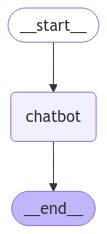

In [46]:
graph = graph_builder.compile()
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [47]:
# Run the chatbot
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

User: hi
Assistant: Hello! How can I assist you today?
User: bye
Assistant: Goodbye! If you have any more questions in the future, feel free to ask. Have a great day!
User: !
Assistant: Hello! How can I assist you today?
User: q
Goodbye!


In [105]:
from typing import Annotated
# from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
class MyCustomNode:
    def __init__(self, llm):
        self.llm = llm
    def __call__(self, state):
        # Implement your custom logic here
        # Access the state and perform actions
        messages = state["messages"]
        response = self.llm.invoke(messages)
        return {"messages": [response]}
graph_builder = StateGraph(State)
# llm = ChatAnthropic(model="claude-3-haiku-20240307")
custom_node = MyCustomNode(llm)
graph_builder.add_node("custom_node", custom_node)

In [106]:
# Set entry and finish points
graph_builder.set_entry_point("custom_node")
graph_builder.set_finish_point("custom_node")

In [104]:
graph = graph_builder.compile()

In [79]:
# Run the chatbot
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": [("user", user_input)],}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

User: sum 4 plus five
Assistant: 4 plus 5 equals 9.
User: q
Goodbye!


In [117]:
conn = sqlite3.connect("abc.sqlite",  check_same_thread=False)
# conn = sqlite3.connect(":memory:",  check_same_thread=False)
memory = SqliteSaver(conn)
graph = graph_builder.compile(checkpointer=memory)

In [ ]:
# Run the chatbot
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": [("user", user_input)],}, config={"configurable": {"thread_id": 1}}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

User: generate a table contacts and add 2 random contacts
Assistant: Sure! Let's create a new table named `contacts` in your SQLite database and add two random contacts to it. Here are the steps:

1. **Create the `contacts` table**:
   ```sql
   CREATE TABLE contacts (
       id INTEGER PRIMARY KEY AUTOINCREMENT,
       name TEXT NOT NULL,
       phone TEXT NOT NULL,
       email TEXT NOT NULL UNIQUE
   );
   ```

2. **Insert two random contacts**:
   ```sql
   INSERT INTO contacts (name, phone, email) VALUES ('Michael Brown', '555-123-4567', 'michael.brown@example.com');
   INSERT INTO contacts (name, phone, email) VALUES ('Emily Davis', '555-234-5678', 'emily.davis@example.com');
   ```

Here is the complete process using the SQLite command-line tool:

1. Open your terminal or command prompt.
2. Start the SQLite command-line tool by typing `sqlite3` followed by the name of your database file. For example:
   ```sh
   sqlite3 mydatabase.db
   ```
3. Create the `contacts` table:
   ```

In [ ]:
# Run the chatbot
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": [("user", user_input)],}, config={"configurable": {"thread_id": 1}}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

User: list users from contacts table in sqlite. Be concise
Assistant: To list users from the `contacts` table in SQLite, use the following SQL command:

```sql
SELECT * FROM contacts;
```

Here is the concise process:

1. Open your terminal or command prompt.
2. Start the SQLite command-line tool:
   ```sh
   sqlite3 mydatabase.db
   ```
3. List all users in the `contacts` table:
   ```sql
   SELECT * FROM contacts;
   ```

This will display all the rows in the `contacts` table. For example:

```
1|Michael Brown|555-123-4567|michael.brown@example.com
2|Emily Davis|555-234-5678|emily.davis@example.com
3|Freddy|555-345-6789|freddy@example.com
```

This way, you can list all users from your `contacts` table in the SQLite database.
User: q
Goodbye!


In [ ]:
# Run the chatbot
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": [("user", user_input)],}, config={"configurable": {"thread_id": 1}}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

User: how many contacts exist, who are? be concise
Assistant: To find out how many contacts exist and who they are, you can use the following SQL commands:

1. **Count the number of contacts**:
   ```sql
   SELECT COUNT(*) FROM contacts;
   ```

2. **List all contacts**:
   ```sql
   SELECT * FROM contacts;
   ```

Here is the concise process:

1. Open your terminal or command prompt.
2. Start the SQLite command-line tool:
   ```sh
   sqlite3 mydatabase.db
   ```
3. Count the number of contacts:
   ```sql
   SELECT COUNT(*) FROM contacts;
   ```

4. List all contacts:
   ```sql
   SELECT * FROM contacts;
   ```

For example, if the output is:

```
4
```

And the list of contacts is:

```
1|John Doe|123-456-7890|john.doe@example.com
2|Jane Smith|234-567-8901|jane.smith@example.com
3|Alice Johnson|345-678-9012|alice.johnson@example.com
4|Freddy|456-789-0123|freddy@example.com
```

Then, there are 4 contacts:

1. John Doe
2. Jane Smith
3. Alice Johnson
4. Freddy
User: q
Goodbye!


In [37]:
# sqlite3_conn = sqlite3.connect('checkpoints.sqlite')
# app = graph_builder.compile(checkpointer=sqlite3_memory_checkpoint)

# final_state = graph.invoke(
#     {"messages": [HumanMessage(content='what is the weather in shanghai tomorrow.')]},
#     config={"configurable": {"thread_id": 1}}
# )

for event in graph.stream({"messages": [("user", user_input)]}):
    for value in event.values():
        print("Assistant:", value["messages"][-1].content)

NameError: name 'HumanMessage' is not defined

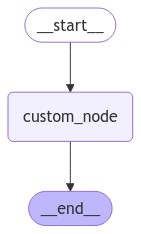

In [30]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [39]:
# Run the chatbot
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

User: hi


AttributeError: '_GeneratorContextManager' object has no attribute 'config_specs'

In [95]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph

builder = StateGraph(int)
builder.add_node("add_one", lambda x: x + 1)
builder.set_entry_point("add_one")
builder.set_finish_point("add_one")
conn = sqlite3.connect("checkpoints2.sqlite",  check_same_thread=False)
memory = SqliteSaver(conn)
graph = builder.compile(checkpointer=memory)
config = {"configurable": {"thread_id": "0"}}
display(graph.get_state(config))
result = graph.invoke(3, config)
display(graph.get_state(config))
result

StateSnapshot(values=4, next=(), config={'configurable': {'thread_id': '0', 'checkpoint_ns': '', 'checkpoint_id': '1ef792dd-027c-6da4-801a-6e746d6891d3'}}, metadata={'source': 'loop', 'writes': {'add_one': 4}, 'step': 26, 'parents': {}}, created_at='2024-09-22T21:58:34.453325+00:00', parent_config={'configurable': {'thread_id': '0', 'checkpoint_ns': '', 'checkpoint_id': '1ef792dd-027b-639f-8019-e025289b4f83'}}, tasks=())

StateSnapshot(values=4, next=(), config={'configurable': {'thread_id': '0', 'checkpoint_ns': '', 'checkpoint_id': '1ef792dd-a02c-6d7d-801d-e0377925439a'}}, metadata={'source': 'loop', 'writes': {'add_one': 4}, 'step': 29, 'parents': {}}, created_at='2024-09-22T21:58:50.988050+00:00', parent_config={'configurable': {'thread_id': '0', 'checkpoint_ns': '', 'checkpoint_id': '1ef792dd-a02a-6348-801c-c2d0203c7016'}}, tasks=())

4